# 11 - Machine Learning: will the lot be approved or rejected?

**Question this model answers:** based on production conditions
(machine, mold, operator, shift, availability...), will this lot be
approved or rejected at final quality inspection?

I use the same Random Forest as the other models, this time as a
**classifier** (predicts a category -- approved/rejected -- instead of
a number).


In [1]:
import sys
sys.path.insert(0, "../machine_learning")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import ml_lib as ml

PROCESSED = "../../datasets/processed"
MODELS = "../../models"
REPORTS = "../../reports"
os.makedirs(MODELS, exist_ok=True)

production = pd.read_csv(f"{PROCESSED}/fact_production_processed.csv", encoding="utf-8-sig", parse_dates=["Date"])
cap_disposition = pd.read_csv(f"{PROCESSED}/fact_cap_disposition_lot_cq_processed.csv", encoding="utf-8-sig")
bottle_disposition = pd.read_csv(f"{PROCESSED}/fact_bottle_disposition_lot_cq_processed.csv", encoding="utf-8-sig")

disposition = pd.concat([
    cap_disposition[["WorkOrder", "FinalLotDecision"]].assign(Family="Cap"),
    bottle_disposition[["WorkOrder", "FinalLotDecision"]].assign(Family="Bottle"),
], ignore_index=True)

rejection_rate = (disposition["FinalLotDecision"] == "Rejected").mean()
print(f"Lots: {len(disposition)}  |  Rejected: {(disposition['FinalLotDecision']=='Rejected').sum()} ({rejection_rate:.1%})")


Lots: 3844  |  Rejected: 172 (4.5%)


## Step 1: build the features (production side only, linked by `WorkOrder`)

In [2]:
model_data = disposition.merge(
    production[["WorkOrder", "Date", "Process", "MachineId", "ToolId", "ShiftNumber", "OperatorId",
                "Availability", "Performance", "RunTimeHours", "SetupTimeHours", "MaterialLotSeq"]],
    on="WorkOrder", how="left"
).dropna()

# the target: 1 if the lot was rejected, 0 if approved
model_data["Target"] = (model_data["FinalLotDecision"] == "Rejected").astype(int)
# 1 if the material lot changed mid-order (sequence > 1)
model_data["MaterialChangedMidOrder"] = (model_data["MaterialLotSeq"] > 1).astype(int)

model_data = pd.get_dummies(
    model_data, columns=["Family", "Process", "MachineId", "ToolId", "OperatorId"], drop_first=True
)

feature_columns = [
    c for c in model_data.columns
    if c not in ("WorkOrder", "FinalLotDecision", "Date", "Target", "MaterialLotSeq")
]
print(f"Model data: {len(model_data)} rows, {len(feature_columns)} features")


Model data: 3751 rows, 65 features


## Step 2: split train and test by date

In [3]:
train, test = ml.split_by_date(model_data, "Date", test_fraction=0.2)
X_train, y_train = train[feature_columns], train["Target"]
X_test, y_test = test[feature_columns], test["Target"]

print(f"Train: {len(train)} rows ({y_train.mean():.1%} rejected)")
print(f"Test:  {len(test)} rows ({y_test.mean():.1%} rejected)")


Train: 3000 rows (4.7% rejected)
Test:  751 rows (3.7% rejected)


## Step 3: train the model

I use `class_weight="balanced"` because a rejected lot is the minority
class (~4%-5% of the data) -- without this, the model would learn that
predicting "Approved" every time already gives a high accuracy, which
is useless for this purpose.


In [4]:
model = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

prediction = model.predict(X_test)
probability = model.predict_proba(X_test)[:, 1]

print(ml.classification_metrics(y_test, prediction, probability))
print()
ml.show_classification_report(y_test, prediction, class_names=("Approved", "Rejected"))


{'Accuracy': 0.8681757656458056, 'Precision': 0.07228915662650602, 'Recall': 0.21428571428571427, 'F1': 0.10810810810810811, 'ROC_AUC': 0.611391029440822}

              precision    recall  f1-score   support

    Approved       0.97      0.89      0.93       723
    Rejected       0.07      0.21      0.11        28

    accuracy                           0.87       751
   macro avg       0.52      0.55      0.52       751
weighted avg       0.93      0.87      0.90       751

Confusion matrix (rows=actual, columns=predicted):
                 Predicted Approved  Predicted Rejected
Actual Approved                 646                  77
Actual Rejected                  22                   6


## Step 4: feature importance

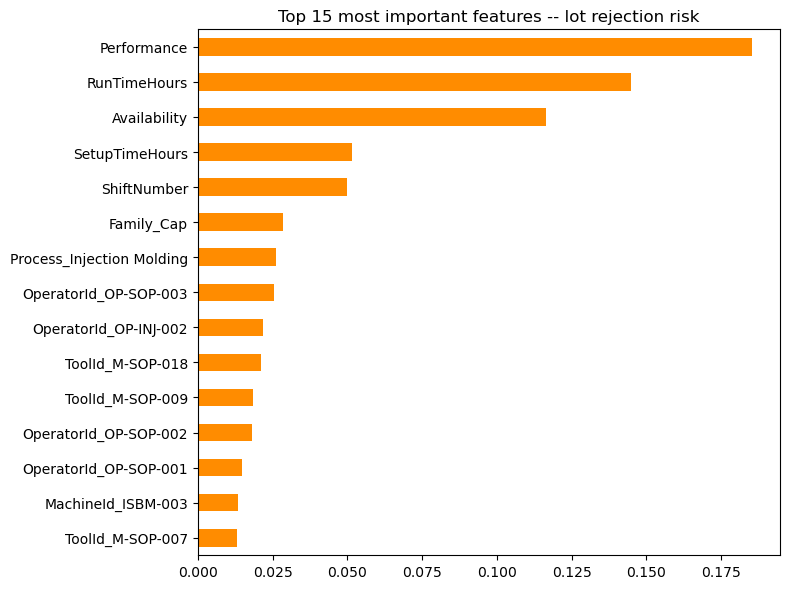

Model saved to ../../models/lot_quality_model.pkl


In [5]:
importance = pd.Series(model.feature_importances_, index=feature_columns)
importance = importance.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
importance.sort_values().plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("Top 15 most important features -- lot rejection risk")
plt.tight_layout()
plt.savefig(f"{REPORTS}/40_ml_lot_quality_feature_importance.png", dpi=150)
plt.show()

ml.save_model(
    model, f"{MODELS}/lot_quality_model.pkl",
    feature_cols=feature_columns, target_col="Target", model_name="Random Forest",
    test_metrics=ml.classification_metrics(y_test, prediction, probability),
)
print(f"Model saved to {MODELS}/lot_quality_model.pkl")


## Step 5: export the results

In [6]:
exported_predictions = test[["WorkOrder", "Date", "FinalLotDecision"]].copy()
exported_predictions["PredictedRejectionRisk"] = probability
exported_predictions["PredictedDecision"] = np.where(prediction == 1, "Rejected", "Approved")

exported_predictions.to_csv(f"{PROCESSED}/ml_predictions_lot_quality.csv", index=False, encoding="utf-8-sig")
print(f"Exported ml_predictions_lot_quality.csv ({len(exported_predictions)} rows)")


Exported ml_predictions_lot_quality.csv (751 rows)


## Summary -- an honest result, even if a modest one

This model's ROC-AUC lands around 0.6-0.65 -- better than a random
guess (0.5), but not by much. That's a real result worth reporting
honestly: in this dataset, the approve/reject decision depends a lot
on AQL sampling variation, not only on production conditions -- so
there isn't a huge amount for the model to learn from machine, mold,
and shift alone.
